# Plot RIO Statistics Along Route

This notebook creates contour maps of median RIO (Risk Index Outcome) values for specific vessel types and overlays:
1. Route points (transect of interest)
2. MPAS-SI mesh points used for interpolation

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as cols
import xarray
import os
from scipy.spatial import KDTree

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.tri as mtri
import cmocean

In [9]:
# Configuration and parameters
years = ['2000']
months = ['05']
classes = ['NIS']  # Vessel type

# RIO statistic to plot: 'median', '5th', or '95th'
rio_statistic = '5th'  # Options: 'median', '5th', '95th'

# File paths
pathBase = '/Users/stephenprice/projects/CINS/ColdHarbor/test-data/v3.LR.historical_seaIceRIO_ensembleStats'
prefix = 'v3.LR.historical_'
mpassiPrefix = '.mpassi.hist.am.timeSeriesStatsDaily.'

# Map output path
mapPath = '/Users/stephenprice/projects/CINS/ColdHarbor/maps'

rad2deg = 180.0 / np.pi
# Conversion factor

In [10]:
# Load MPAS-O mesh lat/lon coordinates
os.chdir(pathBase)
fileIn = '../mpaso-IcoswISC30E3r5-restart.nc'
ds = xarray.open_dataset(fileIn)

lat_mesh = ds.latCell.values * rad2deg
lon_mesh = ds.lonCell.values * rad2deg

# Convert longitude values to same format as route definitions (-180 to 180)
lon_mesh_temp = np.zeros(np.shape(lon_mesh))
for i in np.arange(0, np.size(lon_mesh)):
    if lon_mesh[i] > 180:
        lon_mesh_temp[i] = lon_mesh[i] - 360
    else:
        lon_mesh_temp[i] = lon_mesh[i]

lon_mesh = lon_mesh_temp
del lon_mesh_temp

# Filter to Northern region (>= 60°N) if using reduced area data
ind = np.where(lat_mesh >= 60.0)[0]
lat_mesh = lat_mesh[ind]
lon_mesh = lon_mesh[ind]

print(f"Loaded {len(lat_mesh)} mesh points")

Loaded 22076 mesh points


In [4]:
# Load route track data
fileIn = '../arctic_route_sections.nc'
ds = xarray.open_dataset(fileIn)

# Extract route sections (using EJCD route combination as example)
lat_E = ds.lat_E.values
lon_E = ds.lon_E.values
dis_E = ds.dis_E.values

lat_J = ds.lat_J.values
lon_J = ds.lon_J.values
dis_J = ds.dis_J.values

lat_C = ds.lat_C.values
lon_C = ds.lon_C.values
dis_C = ds.dis_C.values

lat_D = ds.lat_D.values
lon_D = ds.lon_D.values
dis_D = ds.dis_D.values

# Combine route sections into single transect
trans_lat = np.hstack((lat_E, lat_J, lat_C, lat_D))
trans_lon = np.hstack((lon_E, lon_J, lon_C, lon_D))
trans_dist = np.hstack((dis_E, dis_J, dis_C, dis_D))

print(f"Loaded route with {len(trans_lat)} points")

Loaded route with 4216 points


In [12]:
# Find nearest neighbor mesh points for each route point
# Build KDTree for efficient spatial queries
tree = KDTree(list(zip(lon_mesh.flatten(), lat_mesh.flatten())))

# Query for k nearest neighbors
kneighbor = 4
d, inds = tree.query(list(zip(trans_lon, trans_lat)), k=kneighbor)

print(f"Found {kneighbor} nearest neighbors for each of {len(trans_lat)} route points")

Found 4 nearest neighbors for each of 4216 route points


In [13]:
# Load RIO ensemble statistics for specified vessel type
os.chdir(pathBase)

year = years[0]
month = months[0]
cs = classes[0]

fileIn = prefix + cs + '_EnsStats' + mpassiPrefix + year + '-' + month + '-01.nc'
print(f'Reading RIO data from: {fileIn}')
dataIn = xarray.open_dataset(fileIn)

# Extract RIO values based on selected statistic
if rio_statistic == 'median':
    RIOData = dataIn.timeDaily_avg_RIO_ensembleMedian.values
    stat_label = 'Median'
elif rio_statistic == '5th':
    RIOData = dataIn.timeDaily_avg_RIO_ensemble5th.values
    stat_label = '5th Percentile'
elif rio_statistic == '95th':
    RIOData = dataIn.timeDaily_avg_RIO_ensemble95th.values
    stat_label = '95th Percentile'
else:
    raise ValueError(f"Invalid statistic: {rio_statistic}. Choose 'median', '5th', or '95th'")

ndays = np.size(RIOData, axis=0)
ncells = np.size(RIOData, axis=1)

print(f"Loaded RIO {stat_label} data: {ndays} days, {ncells} cells")

Reading RIO data from: v3.LR.historical_NIS_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2000-05-01.nc
Loaded RIO 5th Percentile data: 31 days, 22076 cells


In [14]:
# Define plotting function
def plot_rio_with_overlays(lon_mesh, lat_mesh, RIO, trans_lon, trans_lat, 
                           inds, vessel_type, stat_label='Median',
                           time_index=15, extent=(-180, 180, 65, 90),
                           dlon=0.25, dlat=0.25, vmin=-20.0, vmax=30.0, 
                           level_step=2.0, cmap=cmocean.cm.tempo,
                           figsize=(20, 20), dpi=300):
    """
    Create contour map of RIO data with route and mesh point overlays.
    
    Parameters:
    -----------
    lon_mesh, lat_mesh : array-like
        Mesh coordinates
    RIO : array-like
        RIO values with shape (ndays, ncells)
    trans_lon, trans_lat : array-like
        Route coordinates
    inds : array-like
        Indices of nearest neighbor mesh points for each route point
    vessel_type : str
        Vessel class identifier
    stat_label : str
        Label for statistic being plotted (e.g., 'Median', '5th Percentile')
    time_index : int
        Day index to plot (default: 15)
    extent : tuple
        Map extent (lon_min, lon_max, lat_min, lat_max)
    vmin, vmax : float
        Color scale limits
    level_step : float
        Contour level spacing
    cmap : colormap
        Matplotlib colormap
    figsize, dpi : tuple, int
        Figure size and resolution
        
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    # Projections
    noProj = ccrs.PlateCarree()
    mapProj = ccrs.NorthPolarStereo(central_longitude=0)
    
    # Prepare 1D data arrays
    lon1 = np.asarray(lon_mesh).ravel()
    lat1 = np.asarray(lat_mesh).ravel()
    z1 = np.asarray(RIO)[time_index, :].ravel()
    
    # Remove NaNs
    good = np.isfinite(lon1) & np.isfinite(lat1) & np.isfinite(z1)
    lon1, lat1, z1 = lon1[good], lat1[good], z1[good]
    
    # Create structured grid for interpolation
    lon_min, lon_max, lat_min, lat_max = extent
    lon_grid = np.arange(lon_min, lon_max + 0.5 * dlon, dlon)
    lat_grid = np.arange(lat_min, lat_max + 0.5 * dlat, dlat)
    LON, LAT = np.meshgrid(lon_grid, lat_grid)
    
    # Interpolate unstructured data to structured grid
    tri = mtri.Triangulation(lon1, lat1)
    interp = mtri.LinearTriInterpolator(tri, z1)
    Z = interp(LON, LAT)
    Z = np.ma.masked_invalid(Z)
    
    # Create figure and axes
    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = plt.axes(projection=mapProj)
    ax.set_extent(extent, crs=noProj)
    
    # Add gridlines
    ax.gridlines(draw_labels=True, x_inline=False, y_inline=False,
                 color="w", linestyle=":", zorder=50)
    
    # Create filled contours
    clevels = np.arange(vmin, vmax + 0.5 * level_step, level_step)
    cf = ax.contourf(LON, LAT, Z, levels=clevels, cmap=plt.get_cmap(cmap),
                     extend="neither", transform=noProj, zorder=5)
    
    # Add colorbar
    cbar = plt.colorbar(cf, ax=ax, shrink=0.75, pad=0.03, 
                        orientation="vertical")
    cbar.set_label(f"RIO {stat_label}", fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    
    # Overlay route points (in red)
    ax.plot(np.asarray(trans_lon), np.asarray(trans_lat),
            linestyle="None", marker=".", markersize=3, color="red",
            transform=noProj, zorder=60, label="Route points")
    
    # Overlay mesh points used for interpolation (in black)
    inds_use = np.asarray(inds)[:, 1:]  # Skip first column
    flat_inds = np.unique(inds_use.ravel())
    ax.plot(np.asarray(lon_mesh)[flat_inds],
            np.asarray(lat_mesh)[flat_inds],
            linestyle="None", marker=".", markersize=0.5,
            markerfacecolor="none", color="black",
            transform=noProj, zorder=61, label="Mesh points")
    
    # Add land and coastlines on top
    ax.add_feature(cfeature.LAND, facecolor="0.85", edgecolor="none", 
                   zorder=100)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=101)
    ax.add_feature(cfeature.LAKES, facecolor="0.85", edgecolor="none", 
                   zorder=100)
    
    # Add title
    ax.set_title(f"RIO {stat_label} - Vessel Type: {vessel_type}, Day: {time_index+1}", 
                 fontsize=16, weight='bold')
    
    return fig, ax

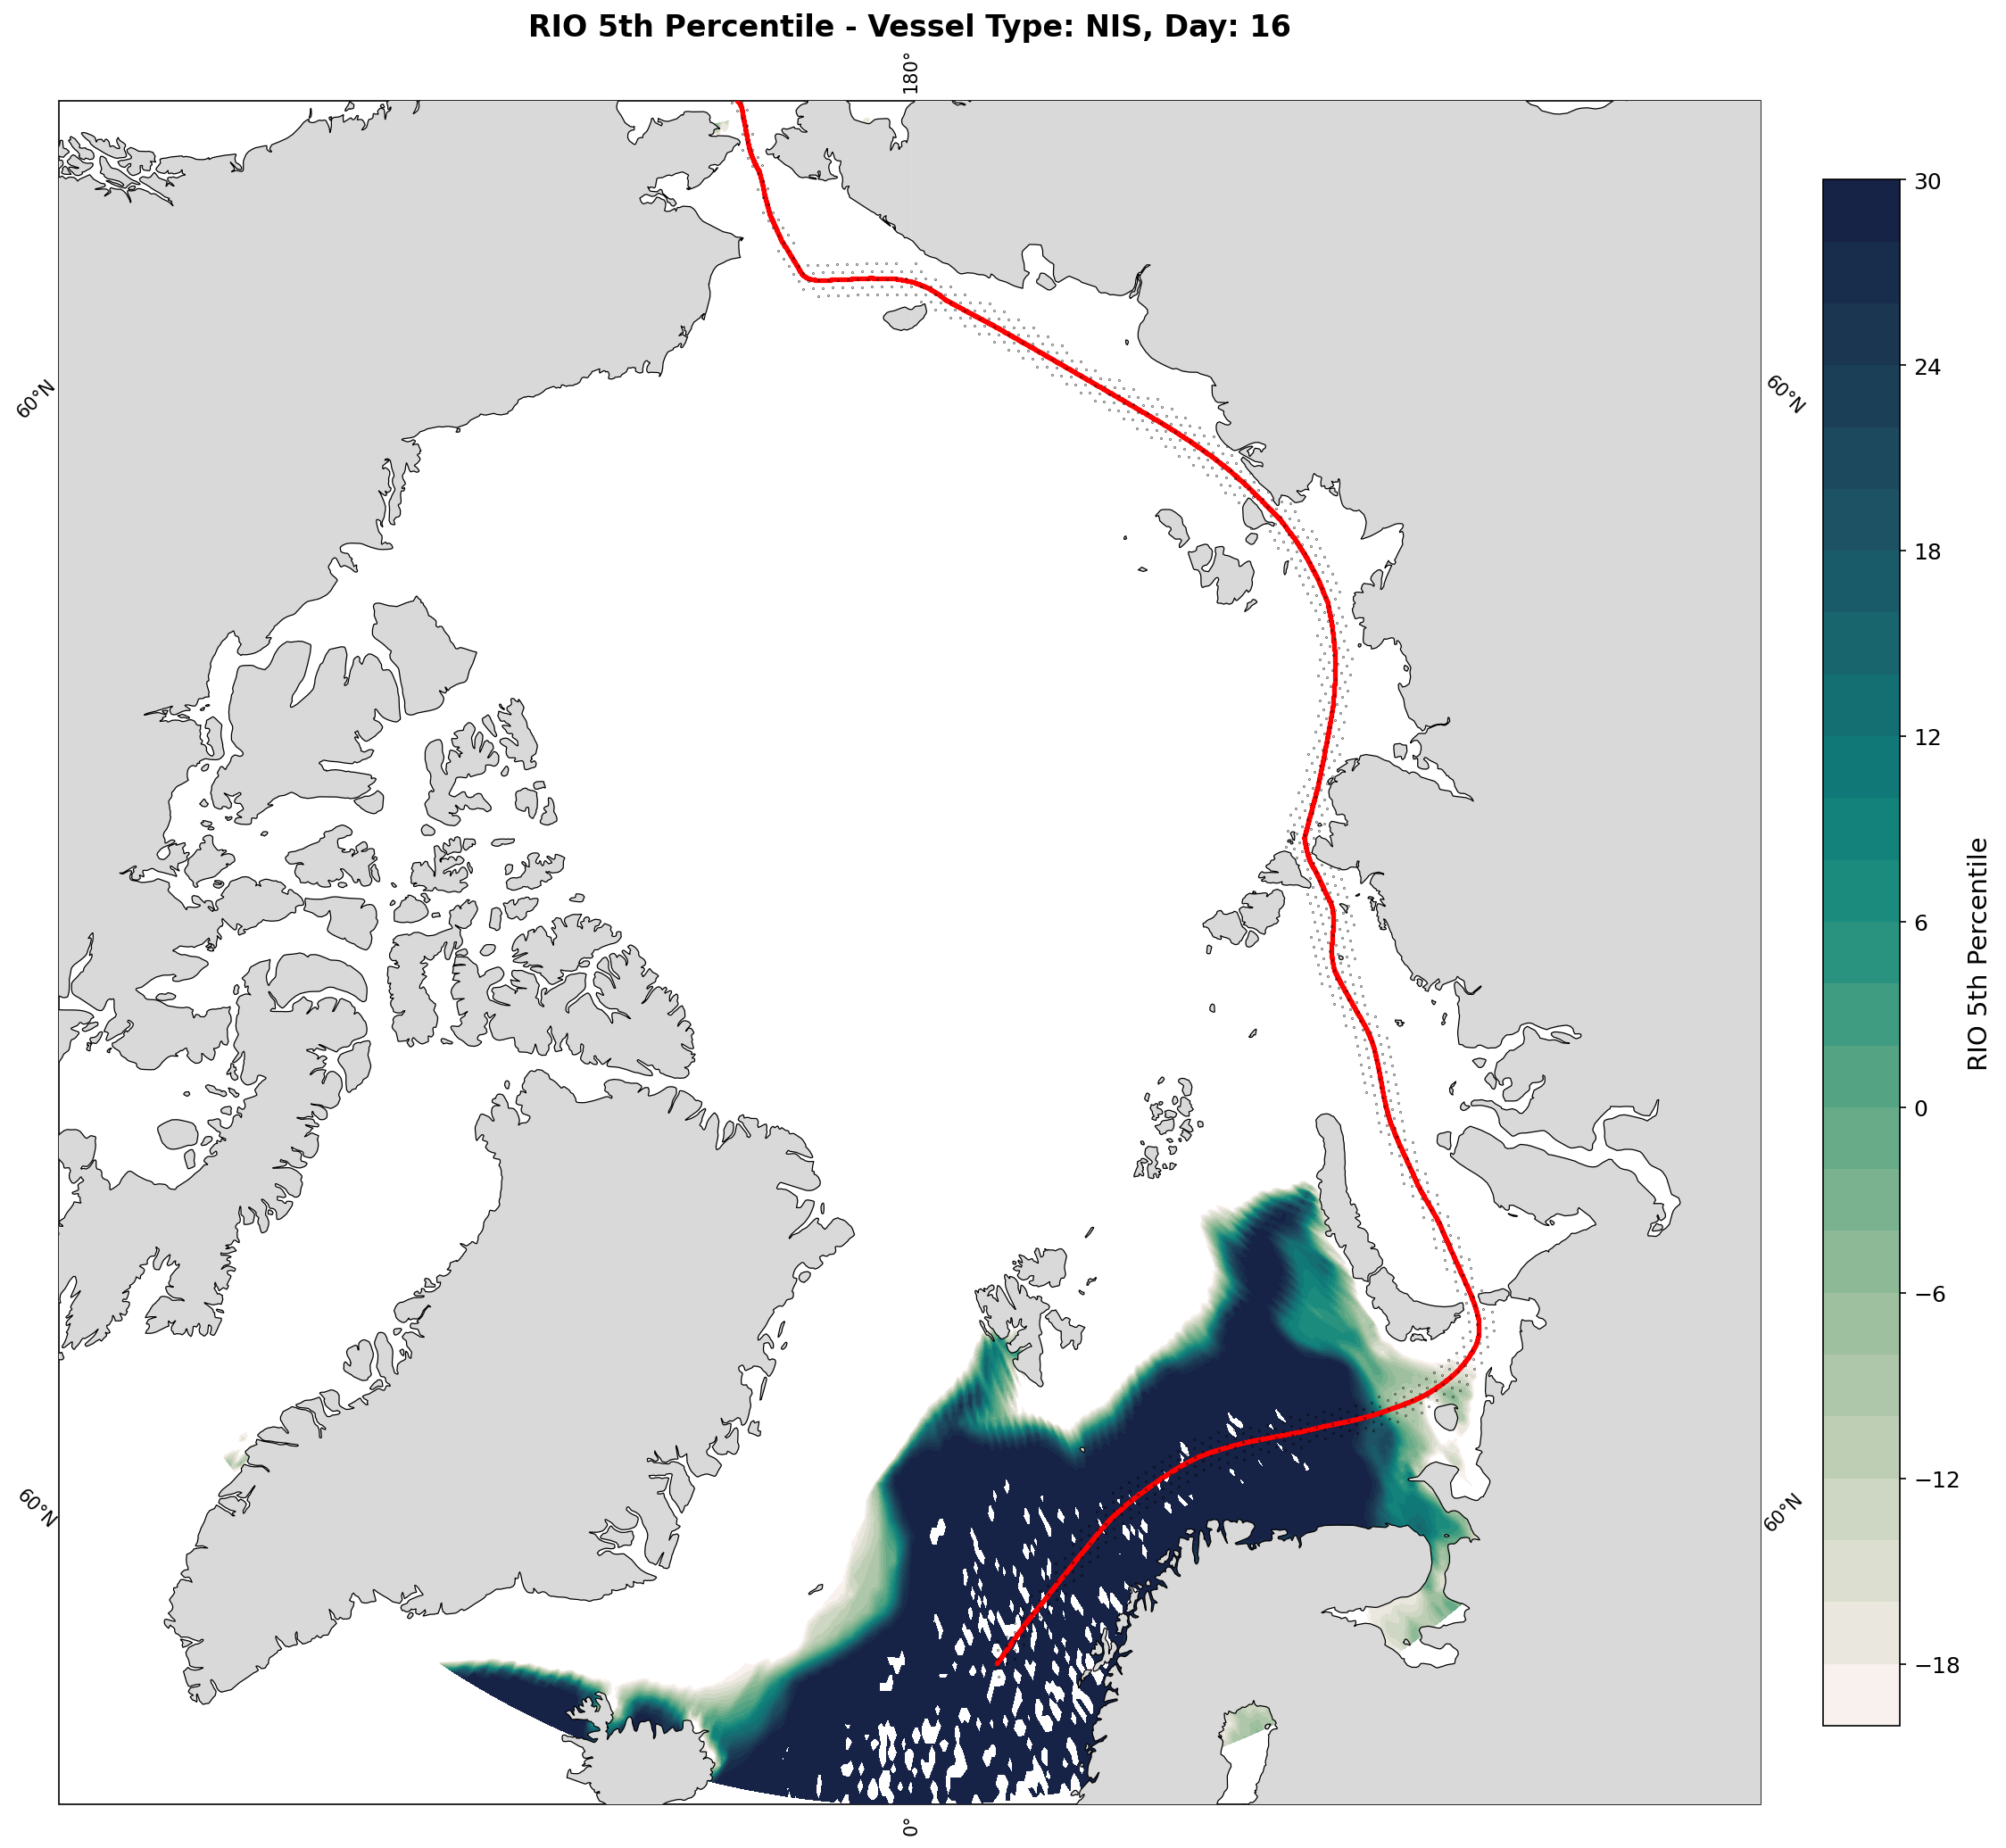

In [15]:
# Create the plot with overlays
time_index = 15  # Day 16 of the month
extent = (-180, 180, 65, 90)  # Arctic region

fig, ax = plot_rio_with_overlays(
    lon_mesh=lon_mesh,
    lat_mesh=lat_mesh,
    RIO=RIOData,
    trans_lon=trans_lon,
    trans_lat=trans_lat,
    inds=inds,
    vessel_type=cs,
    stat_label=stat_label,
    time_index=time_index,
    extent=extent,
    dlon=0.25,
    dlat=0.25,
    vmin=-20,
    vmax=30,
    level_step=2,
    cmap=cmocean.cm.tempo,
    figsize=(20, 20),
    dpi=150  # Reduced for faster display
)

plt.show()

In [ ]:
# Optional: Save figure to file
os.chdir(mapPath)
output_filename = f'RIO_map_{rio_statistic}_{cs}_{year}-{month}_day{time_index+1}.png'
fig.savefig(output_filename, bbox_inches='tight', dpi=300)
print(f'Figure saved to: {mapPath}/{output_filename}')

## Customization Options

To modify the visualization, you can adjust:

### Vessel Types
Change `classes = ['NIS']` to any of: `'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'IAsuper', 'IA', 'IB', 'IC', 'NIS'`

### Time Period
- Modify `years` list (e.g., `['2000', '2001', '2002']`)
- Modify `months` list (e.g., `['01', '02', '03']`)
- Change `time_index` to select different day (0-30)

### Route Selection
Modify the route combination in the "Load route track data" cell:
- Current: `(E, J, C, D)` sections
- Alternative example: `(A, B, I, H)` sections

### Map Appearance
In the plotting call, adjust:
- `extent`: Map boundaries (lon_min, lon_max, lat_min, lat_max)
- `vmin`, `vmax`: Color scale range
- `level_step`: Contour interval
- `cmap`: Color scheme (try `cmocean.cm.ice`, `cmocean.cm.balance`, etc.)
- `figsize`, `dpi`: Figure dimensions and resolution